# Base Networks Comparison Analysis

In [50]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [51]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base_"

# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


### Check

In [52]:
# --- Verification Step: Check if lines were extended ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines:
        if n.lines.s_nom.equals(n.lines.s_nom_opt):
            print(f"Verification PASSED for '{name}' network: Line capacities were not extended (s_nom equals s_nom_opt).")
        else:
            diff_count = (n.lines.s_nom != n.lines.s_nom_opt).sum()
            print(f"Verification FAILED for '{name}' network: {diff_count} lines have different s_nom and s_nom_opt.")
    else:
        print(f"Verification NOTE for '{name}' network: No 's_nom_opt' column found; assuming lines were not extendable.")

Verification PASSED for 'windy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'notwindy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'windvariability' network: Line capacities were not extended (s_nom equals s_nom_opt).


In [53]:
# --- Fix Step: If verification fails, disable line extension on the base network ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines and not n.lines.s_nom.equals(n.lines.s_nom_opt):
        print(f"Fixing base network for '{name}'...")
        
        # Construct the path to the original base network in the 'resources' directory
        folder_name = f"germany_base_{name}"
        base_network_path = f"{home}/pypsa-eur/resources/{folder_name}/networks/base_s_{cluster}_elec_.nc"
        
        # Check if the file exists before trying to modify it
        if not os.path.exists(base_network_path):
            print(f"ERROR: Base network file not found at {base_network_path}. Skipping fix.")
            continue

        # Load the original base network
        base_n = pypsa.Network(base_network_path)
        
        # Set s_nom_extendable to False
        for component in base_n.iterate_components(["Line", "Link"]):
            if "s_nom_extendable" in component.df.columns:
                component.df["s_nom_extendable"] = False
            
        # Save the corrected network back to its original location
        base_n.export_to_netcdf(base_network_path)
        print(f"'{name}' base network at {base_network_path} has been updated to disable line extensions.")
        print("Warning: Remember to rerun solve to apply the changes!")

In [54]:
n1.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04   
            Offshore Wind (AC)        1.116374e+04        1.116374e+04   
            Onshore Wind              7.333207e+04        7.333207e+04   
            Open-Cycle Gas            6.112744e+03        6.112744e+03   
            Run of River              4.014119e+03        4.014119e+03   
            Solar                     4.877125e+04        4.877125e+04   
            biomass                   8.020002e+03        8.020002e+03   
            coal                      2.035194e+04        2.035194e+04   
            geothermal                2.690000e+01        2.690000e+01   
            lignite                   1.945703e+04        1.945703e+04   
            oil                       5.684346e+03        5.684346e+03   
            waste                     3.127659e+03        3.127659e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.806179e+02        0.000000e+00   
            H2 Fuel Cell              7.447056e+02        0.000000e+00   
            battery charger           2.497960e+02        0.000000e+00   
            battery discharger        2.549469e+02        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           2.785833e+02        0.000000e+00   
            Hydrogen Storage          1.663022e+03        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    4.807000e-02  0.000000e+00    4.807000e-02   
            Offshore Wind (AC)    2.490658e+04  0.000000e+00    2.490658e+04   
            Onshore Wind          1.020955e+06  0.000000e+00    1.020955e+06   
            Open-Cycle Gas        5.547000e-02  0.000000e+00    5.547000e-02   
            Run of River          3.950972e+04  0.000000e+00    3.950972e+04   
            Solar                 6.549729e+04  0.000000e+00    6.549729e+04   
            biomass               1.407690e+04  0.000000e+00    1.407690e+04   
            coal                  5.365307e+04  0.000000e+00    5.365307e+04   
            geothermal            4.673510e+02  0.000000e+00    4.673510e+02   
            lignite               8.700000e-03  0.000000e+00    8.700000e-03   
            oil                   2.243000e-02  0.000000e+00    2.243000e-02   
            waste                 1.220310e+02  0.000000e+00    1.220310e+02   
Line        AC                    4.226340e+06  4.333443e+06   -1.071029e+05   
Link        H2 Electrolysis       0.000000e+00  4.334648e+03   -4.334648e+03   
            H2 Fuel Cell          0.000000e+00  3.031653e+03   -3.031653e+03   
            battery charger       0.000000e+00  5.348002e+03   -5.348002e+03   
            battery discharger    0.000000e+00  5.239950e+03   -5.239950e+03   
Load        -                     0.000000e+00  1.179665e+06   -1.179665e+06   
StorageUnit Pumped Hydro Storage  1.998976e+04  2.746215e+04   -7.472389e+03   
            Reservoir & Dam       2.942387e+03  0.000000e+00    2.942387e+03   
Store       Battery Storage       7.825939e+02  7.825939e+02    0.000000e+00   
            Hydrogen Storage      1.789155e+03  1.789155e+03    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000     6.497065e-08  738795.03185   
            Offshore Wind (AC)         0.00000     9.295934e-02  211310.89957   
            Onshore Wind               0.00000     5.800978e-01  499821.67390   
            Open-Cycle Gas             0.00000     3.778990e-07  146705.79388   
            Run of River               0.00000     4.101120e-01     569.66604   
    

In [55]:
n2.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04   
            Offshore Wind (AC)        1.116374e+04        1.116374e+04   
            Onshore Wind              7.333207e+04        7.333207e+04   
            Open-Cycle Gas            6.112744e+03        6.112744e+03   
            Run of River              4.014119e+03        4.014119e+03   
            Solar                     4.877125e+04        4.877125e+04   
            biomass                   8.020002e+03        8.020002e+03   
            coal                      2.035194e+04        2.035194e+04   
            geothermal                2.690000e+01        2.690000e+01   
            lignite                   1.945703e+04        1.945703e+04   
            oil                       5.684346e+03        5.684346e+03   
            waste                     3.127659e+03        3.127659e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.751000e-01        0.000000e+00   
            H2 Fuel Cell              7.492000e-02        0.000000e+00   
            battery charger           6.785972e+02        0.000000e+00   
            battery discharger        6.925903e+02        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           2.243117e+03        0.000000e+00   
            Hydrogen Storage          2.520150e+02        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    4.907098e+03  0.000000e+00    4.907098e+03   
            Offshore Wind (AC)    8.316623e+03  0.000000e+00    8.316623e+03   
            Onshore Wind          4.943494e+04  0.000000e+00    4.943494e+04   
            Open-Cycle Gas        3.626903e+01  0.000000e+00    3.626903e+01   
            Run of River          6.387135e+04  0.000000e+00    6.387135e+04   
            Solar                 2.473219e+05  0.000000e+00    2.473219e+05   
            biomass               1.918619e+05  0.000000e+00    1.918619e+05   
            coal                  3.818374e+05  0.000000e+00    3.818374e+05   
            geothermal            6.455891e+02  0.000000e+00    6.455891e+02   
            lignite               3.453952e+05  0.000000e+00    3.453952e+05   
            oil                   3.416100e-01  0.000000e+00    3.416100e-01   
            waste                 2.176634e+04  0.000000e+00    2.176634e+04   
Line        AC                    2.516917e+06  2.664692e+06   -1.477745e+05   
Link        H2 Electrolysis       0.000000e+00  2.015790e+00   -2.015790e+00   
            H2 Fuel Cell          0.000000e+00  1.409850e+00   -1.409850e+00   
            battery charger       0.000000e+00  4.540771e+03   -4.540771e+03   
            battery discharger    0.000000e+00  4.449029e+03   -4.449029e+03   
Load        -                     0.000000e+00  1.300023e+06   -1.300023e+06   
StorageUnit Pumped Hydro Storage  3.104180e+04  4.138912e+04   -1.034733e+04   
            Reservoir & Dam       5.760189e+03  0.000000e+00    5.760189e+03   
Store       Battery Storage       4.425985e+03  4.425985e+03    1.000000e-05   
            Hydrogen Storage      1.465800e-01  1.465800e-01    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000         0.006642  733887.98157   
            Offshore Wind (AC)         0.00000         0.031040       0.00635   
            Onshore Wind               0.00000         0.028089       0.45275   
            Open-Cycle Gas             0.00000         0.000247  146669.58033   
            Run of River               0.00000         0.662986       0.53659   
    

In [56]:
n3.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04   
            Offshore Wind (AC)        1.116374e+04        1.116374e+04   
            Onshore Wind              7.333207e+04        7.333207e+04   
            Open-Cycle Gas            6.112744e+03        6.112744e+03   
            Run of River              4.014119e+03        4.014119e+03   
            Solar                     4.877125e+04        4.877125e+04   
            biomass                   8.020002e+03        8.020002e+03   
            coal                      2.035194e+04        2.035194e+04   
            geothermal                2.690000e+01        2.690000e+01   
            lignite                   1.945703e+04        1.945703e+04   
            oil                       5.684346e+03        5.684346e+03   
            waste                     3.127659e+03        3.127659e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.005900e-01        0.000000e+00   
            H2 Fuel Cell              4.878000e-02        0.000000e+00   
            battery charger           2.190750e+03        0.000000e+00   
            battery discharger        2.235925e+03        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           1.791124e+04        0.000000e+00   
            Hydrogen Storage          1.259254e+02        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    3.555054e+04  0.000000e+00    3.555054e+04   
            Offshore Wind (AC)    8.419670e+04  0.000000e+00    8.419670e+04   
            Onshore Wind          6.997078e+05  0.000000e+00    6.997078e+05   
            Open-Cycle Gas        2.900434e+03  0.000000e+00    2.900434e+03   
            Run of River          2.613786e+04  0.000000e+00    2.613786e+04   
            Solar                 4.779319e+04  0.000000e+00    4.779319e+04   
            biomass               1.194035e+05  0.000000e+00    1.194035e+05   
            coal                  2.623630e+05  0.000000e+00    2.623630e+05   
            geothermal            5.300046e+02  0.000000e+00    5.300046e+02   
            lignite               1.109102e+05  0.000000e+00    1.109102e+05   
            oil                   1.642100e-01  0.000000e+00    1.642100e-01   
            waste                 1.199749e+04  0.000000e+00    1.199749e+04   
Line        AC                    3.981856e+06  4.209046e+06   -2.271896e+05   
Link        H2 Electrolysis       0.000000e+00  1.261650e+00   -1.261650e+00   
            H2 Fuel Cell          0.000000e+00  8.824000e-01   -8.824000e-01   
            battery charger       0.000000e+00  2.222918e+04   -2.222918e+04   
            battery discharger    0.000000e+00  2.178006e+04   -2.178006e+04   
Load        -                     0.000000e+00  1.368958e+06   -1.368958e+06   
StorageUnit Pumped Hydro Storage  2.233557e+04  2.978080e+04   -7.445231e+03   
            Reservoir & Dam       2.364540e+03  0.000000e+00    2.364540e+03   
Store       Battery Storage       1.851382e+04  1.851382e+04    0.000000e+00   
            Hydrogen Storage      1.684700e-01  1.684600e-01    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000         0.048120  703244.53986   
            Offshore Wind (AC)         0.00000         0.314249   89372.05854   
            Onshore Wind               0.00000         0.397568  105123.00525   
            Open-Cycle Gas             0.00000         0.019770  143805.41581   
            Run of River               0.00000         0.271312      81.40181   
    

### Grid Congestion and Curtailment

##### Marginal Prices

Plotting 'Unnamed Network' network at time 2025-10-26 16:00:00 with peak marginal price 44.17 €/MWh
Plotting 'Unnamed Network' network at time 2025-04-08 05:00:00 with peak marginal price 77.74 €/MWh
Plotting 'Unnamed Network' network at time 2025-10-06 17:00:00 with peak marginal price 92.19 €/MWh


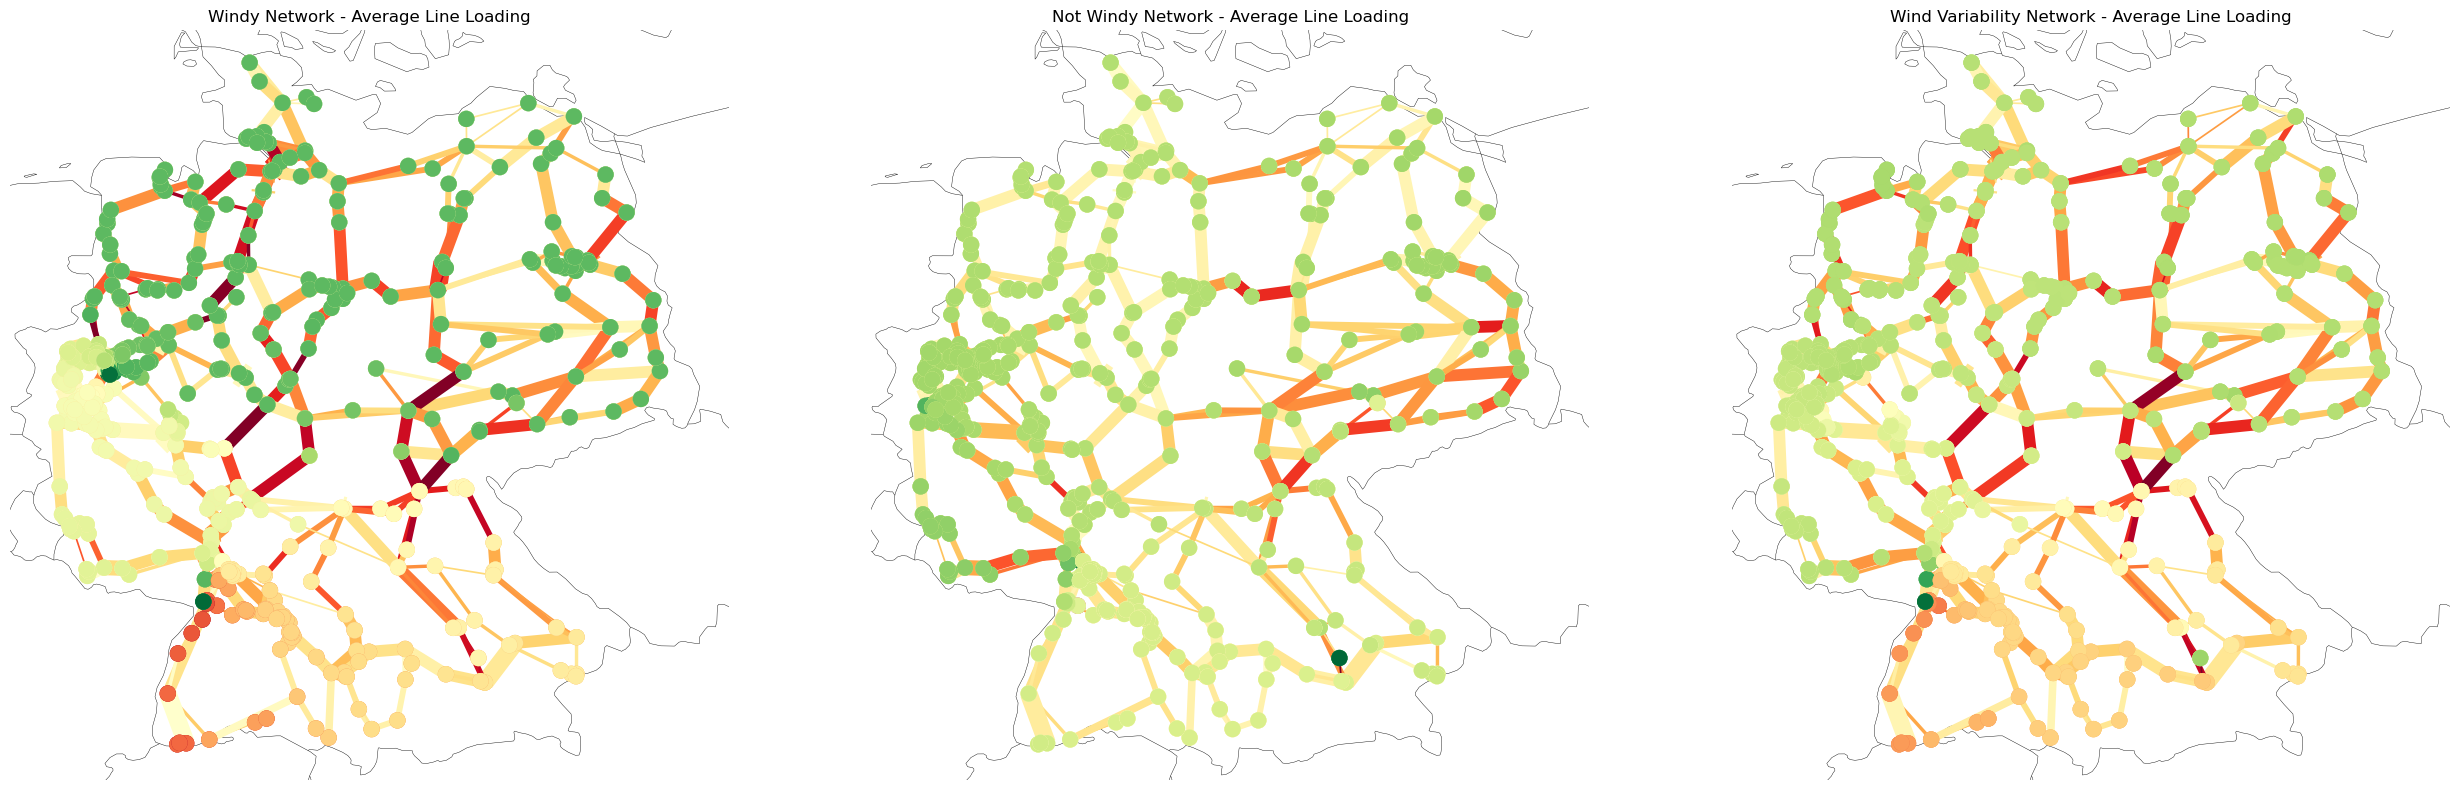

In [57]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01, # Size buses by marginal price
        bus_colors=peak_prices,       # Color buses by marginal price
        bus_cmap='RdYlGn_r',
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

### Load shedding

No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.


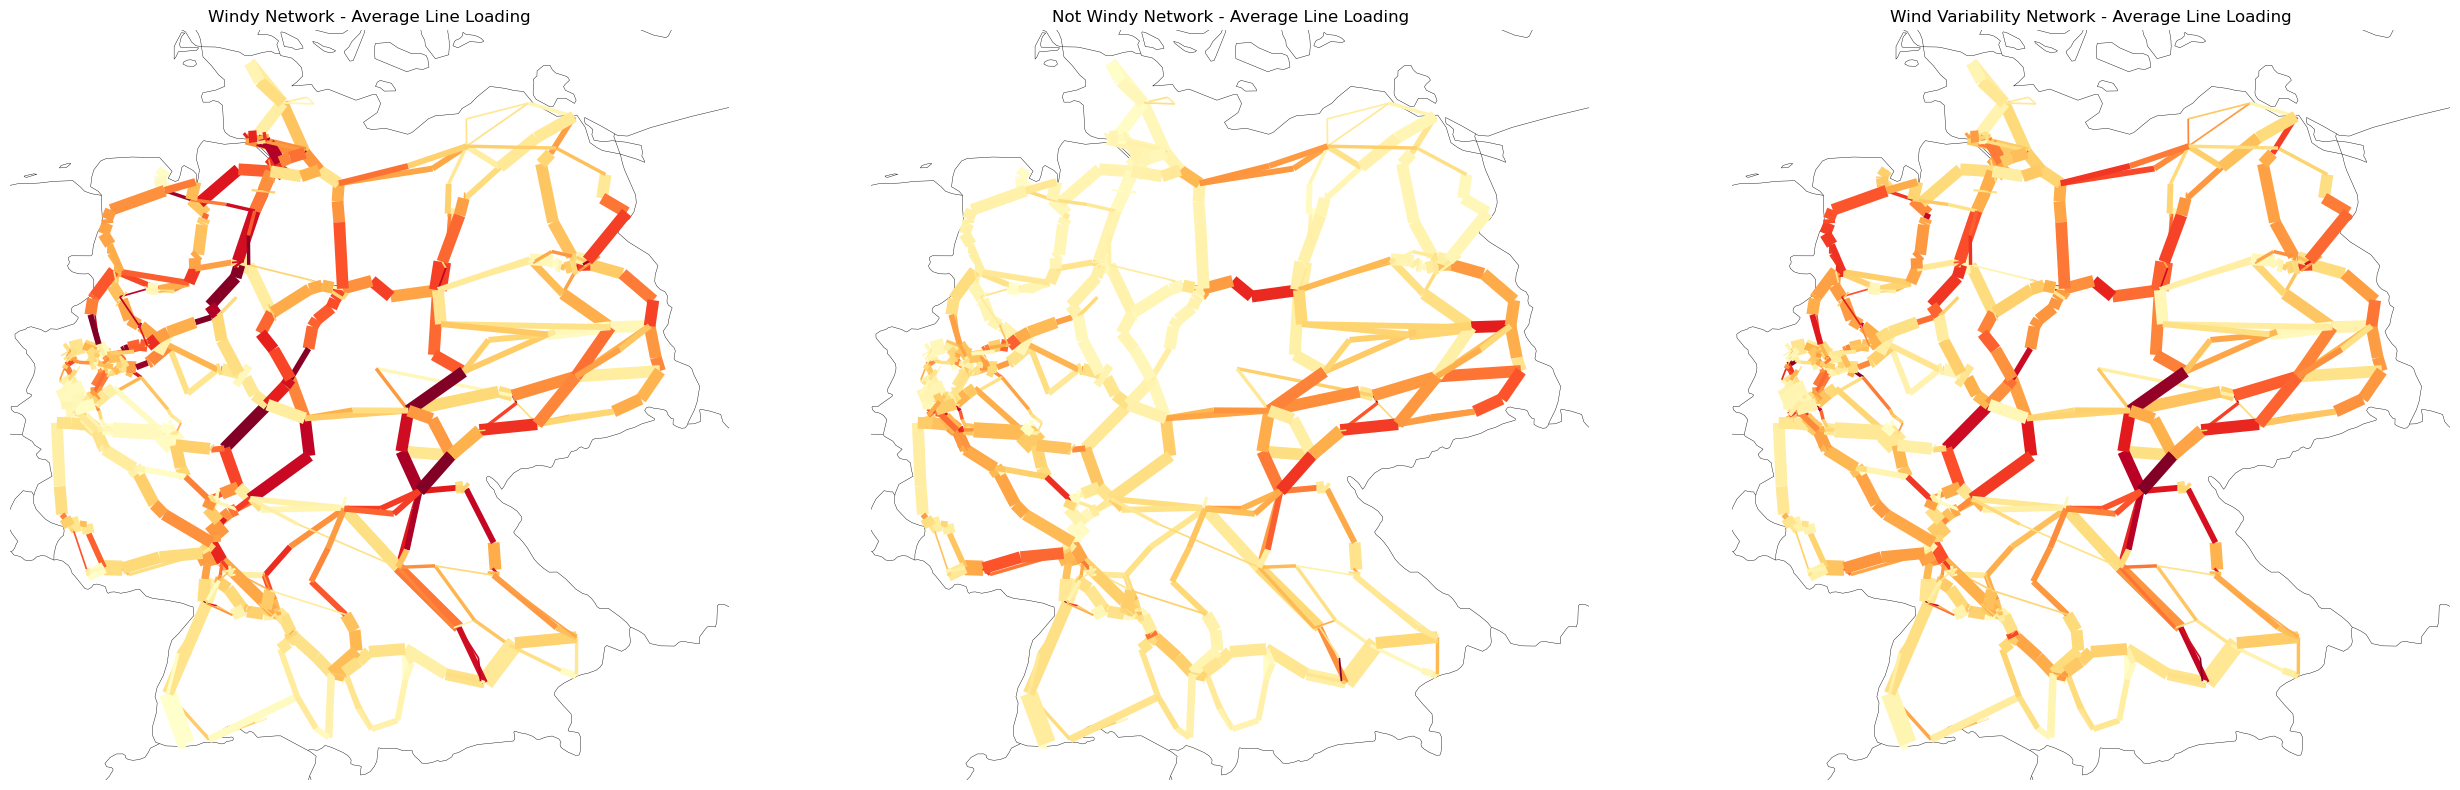

In [58]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        used_carriers = sorted(n.generators.loc[shed_gens, "carrier"].unique())
        print(f"Using load-related carriers: {used_carriers}")

        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )


    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]


    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        #bus_sizes=0.01, # Size buses by unmet load at worst snapshot
        bus_sizes=unmet_load_at_snapshot/5000,
        #bus_colors=unmet_load_at_snapshot,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

In [59]:
# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nWindy Network:")
print(f"  Average loading across all lines: {avg_loading_n1.mean():.2%}")
print(f"  Max average loading: {avg_loading_n1.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n1 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n1 > 0.7).sum()}")

print(f"\nNot Windy Network:")
print(f"  Average loading across all lines: {avg_loading_n2.mean():.2%}")
print(f"  Max average loading: {avg_loading_n2.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n2 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n2 > 0.7).sum()}")

print(f"\nWind Variability Network:")
print(f"  Average loading across all lines: {avg_loading_n3.mean():.2%}")
print(f"  Max average loading: {avg_loading_n3.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n3 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n3 > 0.7).sum()}")
print("=" * 70)


CONGESTION STATISTICS

Windy Network:
  Average loading across all lines: 24.09%
  Max average loading: 69.94%
  Lines with >60% avg loading: 28
  Lines with >70% avg loading: 0

Not Windy Network:
  Average loading across all lines: 15.97%
  Max average loading: 69.97%
  Lines with >60% avg loading: 6
  Lines with >70% avg loading: 0

Wind Variability Network:
  Average loading across all lines: 23.58%
  Max average loading: 69.92%
  Lines with >60% avg loading: 10
  Lines with >70% avg loading: 0


##### Offshore Wind Curtailment

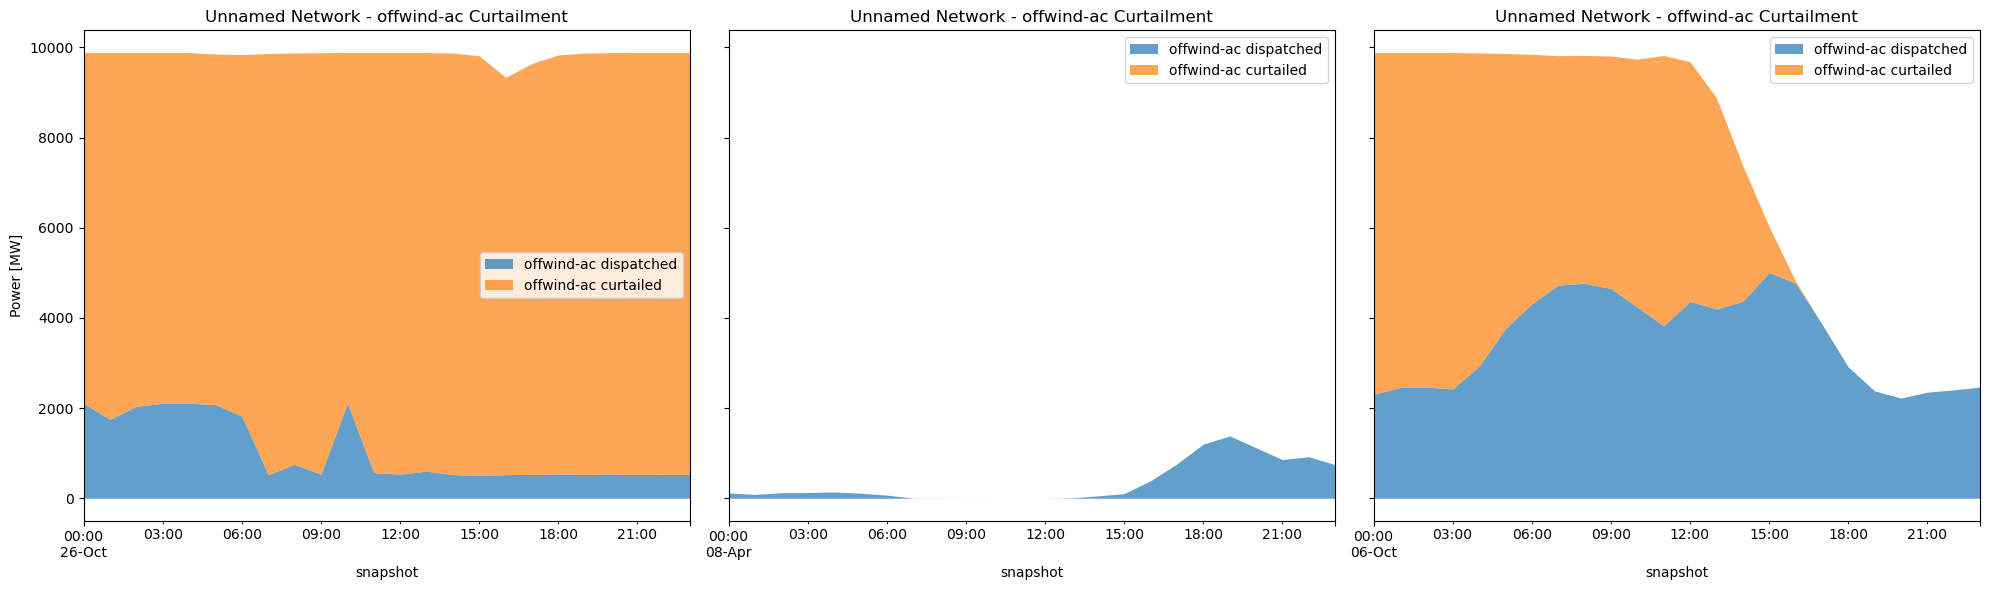

In [60]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])


plt.tight_layout()
plt.show()

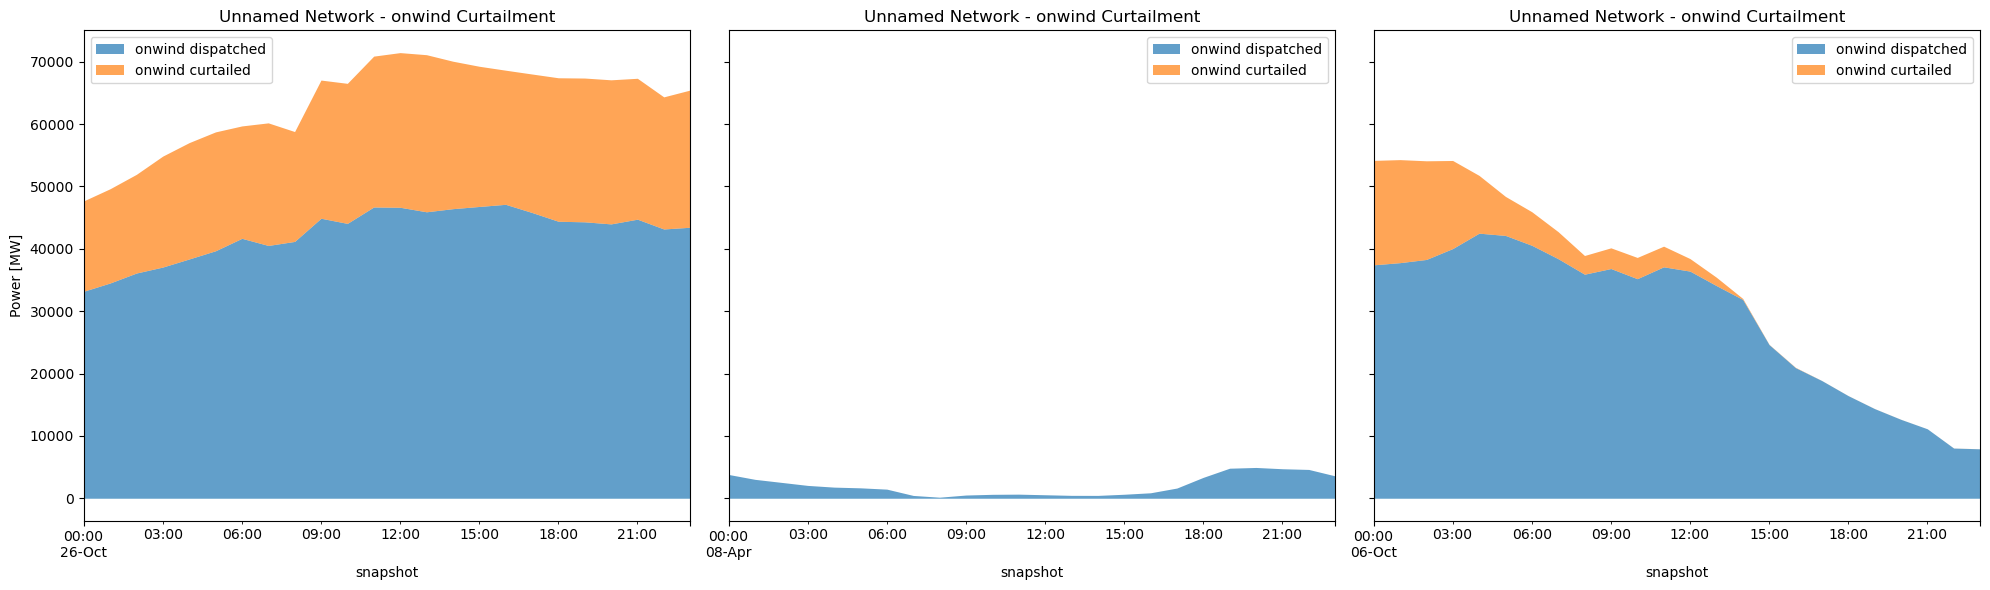

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

In [62]:
p_by_carrier = n1.generators_t.p.T.groupby(n1.generators.carrier).sum().T
print(p_by_carrier.sum())

carrier
CCGT             4.806987e-02
OCGT             5.546704e-02
biomass          1.407690e+04
coal             5.365307e+04
geothermal       4.673510e+02
lignite          8.700092e-03
offwind-ac       2.490658e+04
offwind-dc       0.000000e+00
offwind-float    0.000000e+00
oil              2.242822e-02
onwind           1.020955e+06
ror              3.950972e+04
solar            6.549729e+04
solar-hsat       0.000000e+00
waste            1.220310e+02
dtype: float64


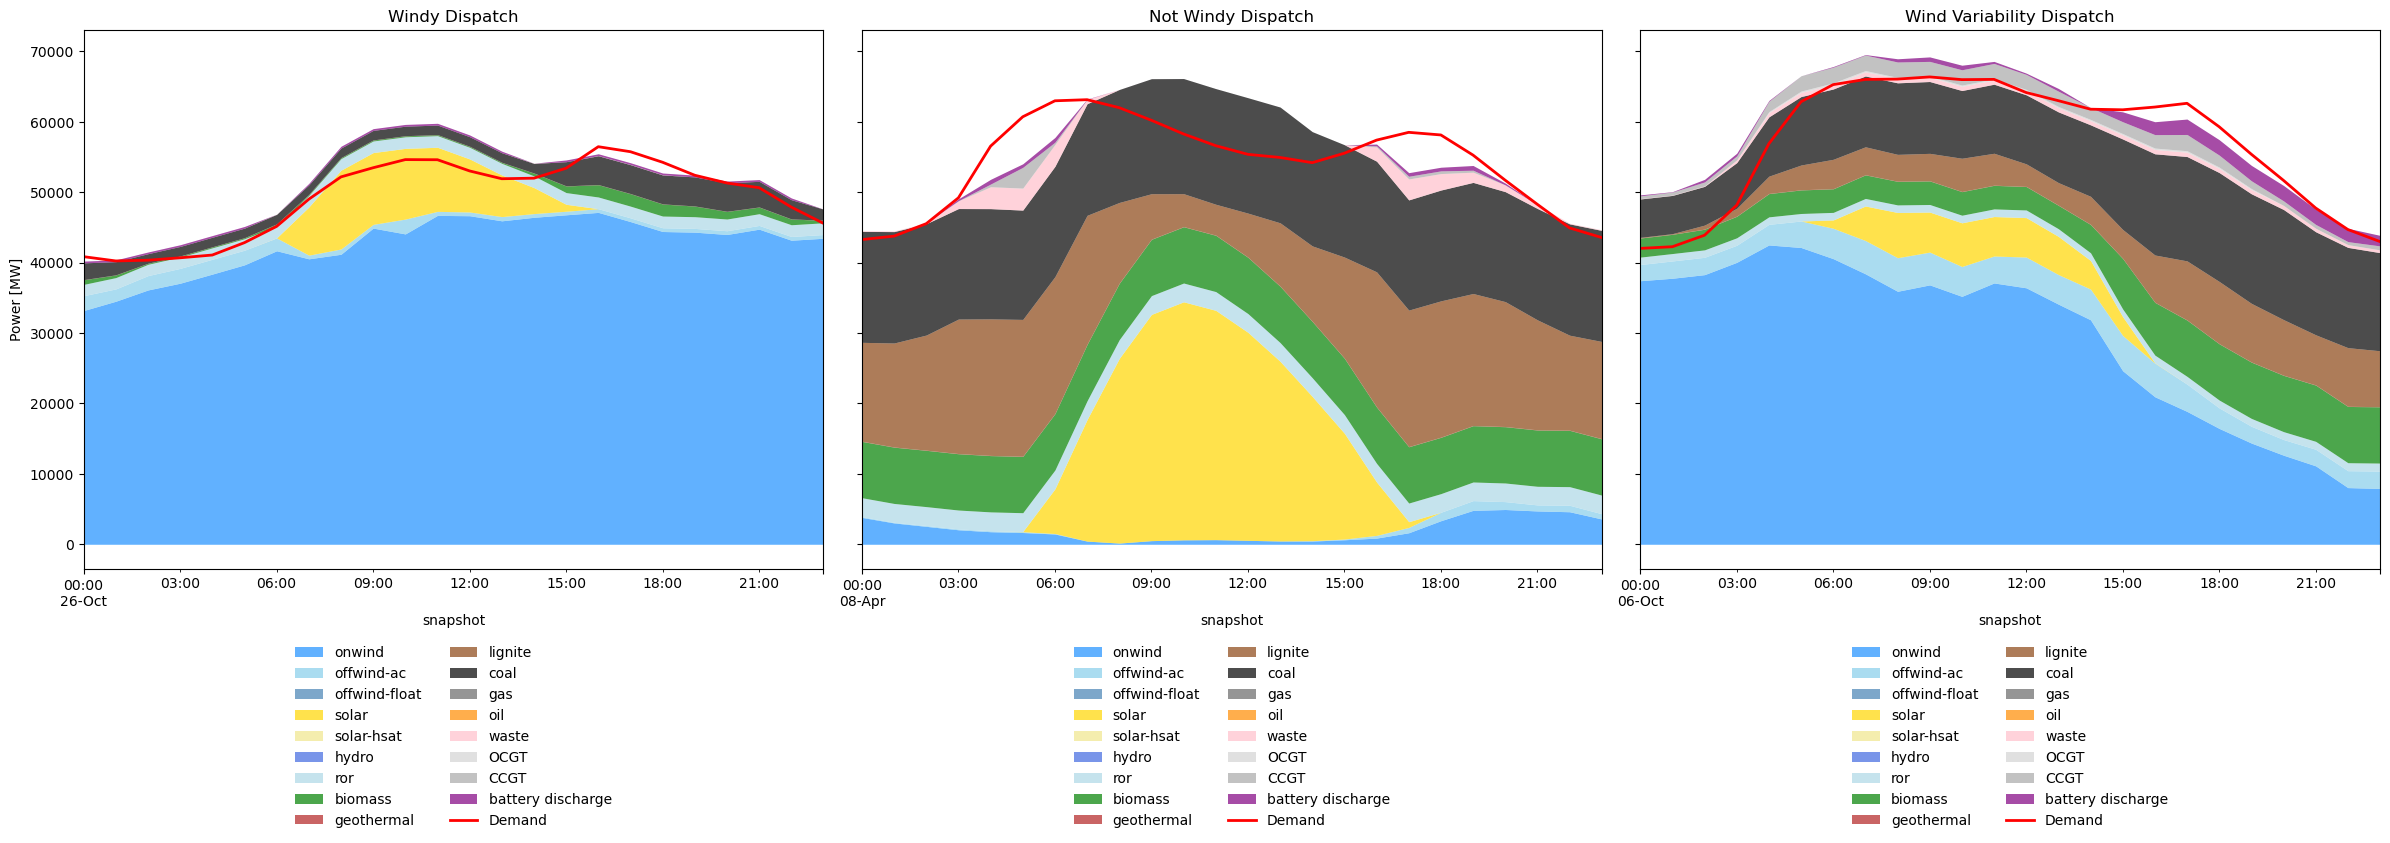

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "dimgray",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "battery discharge": "purple",
}

cols = [
    # Renewables
    "onwind", "offwind-ac", "offwind-float", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "gas", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "battery discharge"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

## Comparison with real word data 

/tmp/ipykernel_81146/206753918.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start date'] = pd.to_datetime(df['Start date'])
/tmp/ipykernel_81146/206753918.py:35: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(df.columns, axis=1).sum()
/tmp/ipykernel_81146/206753918.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start date'] = pd.to_datetime(df['Start date'])
/tmp/ipykernel_81146/206753918.py:35: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(df.columns, axis=1).sum()
/tmp/ipykernel_81146/206753918.py:11: UserWarning: Could not infer f

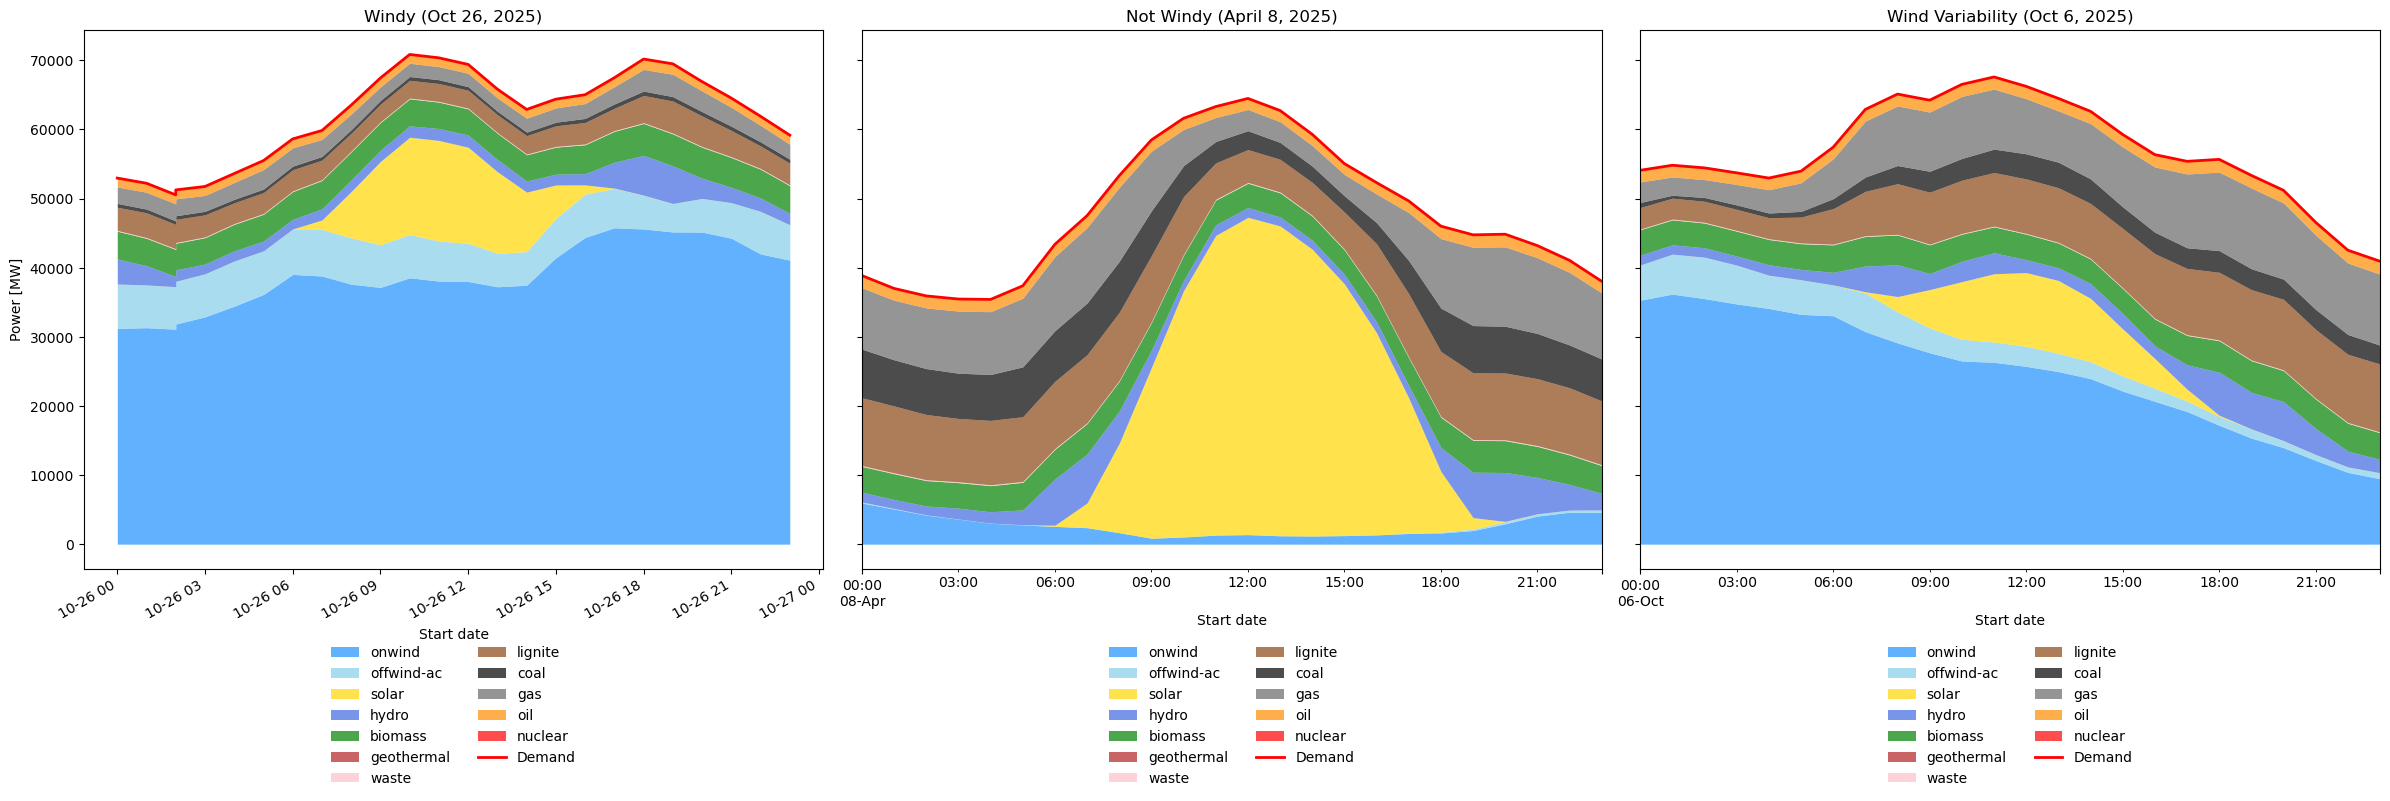

In [64]:
# --- Load and Process Real-World Data ---
real_data_paths = {
    "Windy (Oct 26, 2025)": "/home/lucakristin/Desktop/my_pypsa/actual_generation_data/Actual_generation_202510260000_202510270000_Hour.csv",
    "Not Windy (April 8, 2025)": "/home/lucakristin/Desktop/my_pypsa/actual_generation_data/Actual_generation_202504080000_202504090000_Hour.csv",
    "Wind Variability (Oct 6, 2025)": "/home/lucakristin/Desktop/my_pypsa/actual_generation_data/Actual_generation_202510060000_202510070000_Hour.csv",
}

def load_and_prepare_real_data(path):
    """Loads real generation data and prepares it for plotting."""
    df = pd.read_csv(path, sep=';', thousands=',', na_values=['-'])
    df['Start date'] = pd.to_datetime(df['Start date'])
    df = df.set_index('Start date')
    
    # Clean up column names
    df.columns = [c.replace(' [MWh] Calculated resolutions', '') for c in df.columns]
    
    # Rename columns to match PyPSA carriers
    rename_map = {
        'Biomass': 'biomass',
        'Hydropower': 'hydro',
        'Wind offshore': 'offwind-ac',
        'Wind onshore': 'onwind',
        'Photovoltaics': 'solar',
        'Other renewable': 'waste', # Assumption
        'Nuclear': 'nuclear',
        'Lignite': 'lignite',
        'Hard coal': 'coal',
        'Fossil gas': 'gas',
        'Hydro pumped storage': 'hydro', # Add to hydro
        'Other conventional': 'oil' # Assumption
    }
    df = df.rename(columns=rename_map)
    
    # Group by new carrier names
    df = df.groupby(df.columns, axis=1).sum()

    # Force all columns to numeric, coercing errors
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df.fillna(0)

real_data = {name: load_and_prepare_real_data(p) for name, p in real_data_paths.items()}

# --- Plotting Real-World Data ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# Use the same colors and column order as the PyPSA plots
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "dimgray",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "battery discharge": "purple",
    "nuclear": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac",
    "solar",
    "hydro",
    "biomass", "geothermal", "waste",
    # Conventional
    "lignite", "coal", "gas", "oil",
    "nuclear"
]

for ax, (title, data) in zip(axes, real_data.items()):
    plot_data = data.reindex(columns=cols).fillna(0)
    c = [colors.get(col, "gray") for col in plot_data.columns]
    
    plot_data.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)
    
    # Calculate and plot demand
    demand = plot_data.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")
    
    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

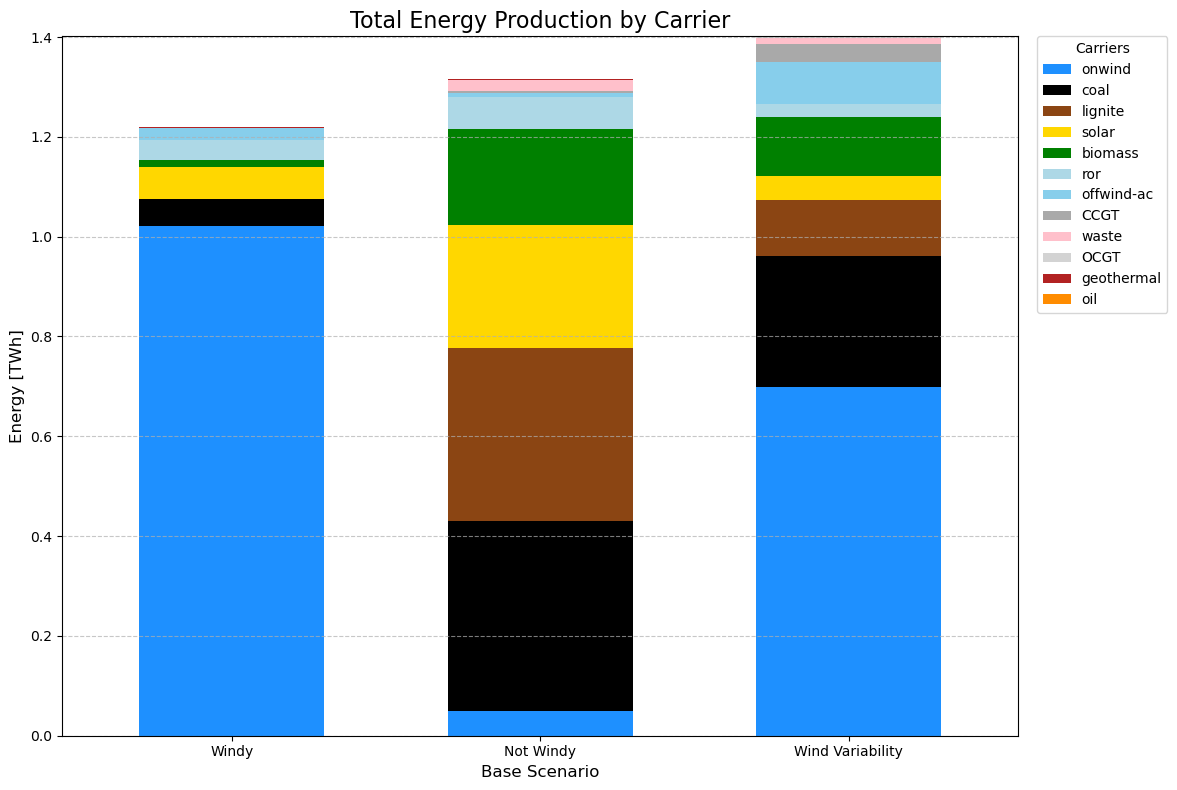

In [66]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]


# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in energy_df.index]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Base Scenario", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()